# Setup


📝 *Import required libraries and files:*

In [98]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import copy
# Text cleaning & preprocessing
import re
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS
# Dimensionality reduction
from umap import UMAP
from hdbscan import HDBSCAN
# Topic modeling
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer


In [99]:
df = pd.read_parquet("../assets/intermediate_dfs/df_sentiment.parquet") 

# 4.2. - BERTopic modelling

### 4.2.1. - Prepare df for model training

In [100]:
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))
df['word_count'].describe().round(1)

count    653426.0
mean         12.2
std          17.4
min           1.0
25%           2.0
50%           6.0
75%          14.0
max         552.0
Name: word_count, dtype: float64

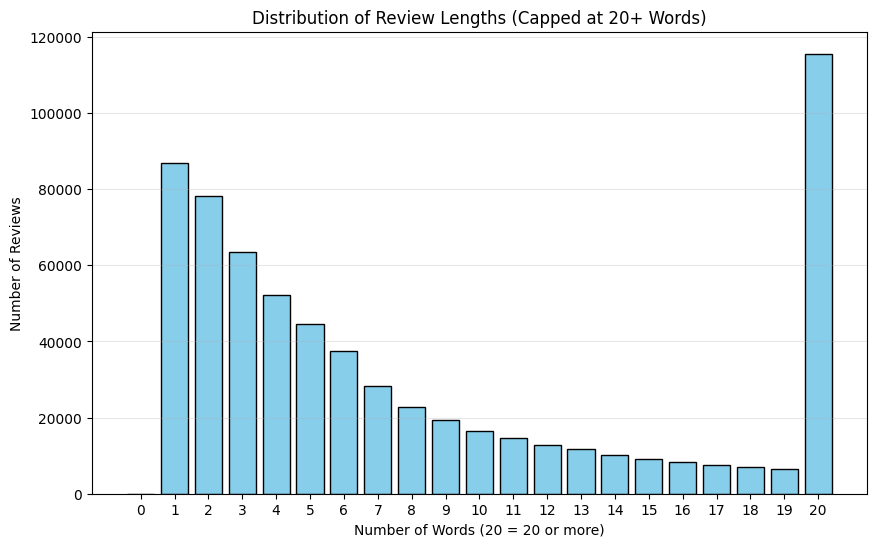

In [101]:
# Calculate number of words per review
df['word_count'] = df['review_text'].apply(lambda x: len(str(x).split()))

# Cap word counts at 20
df['word_count_capped'] = df['word_count'].apply(lambda x: x if x < 20 else 20)

# Count how many reviews per word count
counts = df['word_count_capped'].value_counts().sort_index()

# Ensure we have bins from 0 to 20 (fill missing ones with 0)
counts = counts.reindex(np.arange(0, 21), fill_value=0)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(counts.index, counts.values, color='skyblue', edgecolor='black')
plt.title("Distribution of Review Lengths (Capped at 20+ Words)")
plt.xlabel("Number of Words (20 = 20 or more)")
plt.ylabel("Number of Reviews")
plt.xticks(range(0, 21))
plt.grid(axis='y', alpha=0.3)
plt.show()

In [102]:
print (f"Dataframe shape before filtering short reviews: {df.shape}")
# eliminate rows with less than 2 words in 'review_text'
df = df[df['review_text'].str.split().str.len() >= 4]
df = df[df['review_date'] > pd.Timestamp('2021-10-01')]
print (f"Dataframe shape after filtering short reviews: {df.shape}")
# eliminate reviews that are duplicates
df = df.drop_duplicates(subset=['review_text'], keep='first')
print (f"Dataframe shape after dropping duplicates: {df.shape}")

Dataframe shape before filtering short reviews: (653426, 22)
Dataframe shape after filtering short reviews: (232719, 22)
Dataframe shape after dropping duplicates: (212971, 22)


In [103]:
# Setting basic stop words to favor topics related to functionality issues
PRAISE_WORDS = [
    "amazing", "awesome", "brilliant", "excellent", "fantastic", "love", "nice", "perfect", "star", "stars",
    "awful", "bad", "disappointing", "horrible", "poor", "terrible", "useless", "worst", "best"
]

CUSTOM_STOP_WORDS = [
    "santander", "revolut", "revolute", "revoult", "revlout", "revelout", "hsbc", "barclays", 
    "barclay", "lloyds","lloyd", "monzo", "app", "banking", "bank"
]

STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS

# BERTopic basic cleaning function
def bertopic_cleaning(df: pd.DataFrame, col: str = "review_text"):
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not found in DataFrame.")
    
    df[col] = df[col].apply(lambda x: re.sub(r"http\S+", "", str(x))) # Remove URLs
    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces
    
    for w in STOP_WORDS:
        df[col] = df[col].apply(lambda x: re.sub(rf"\b{re.escape(w)}\b", "", x, flags=re.IGNORECASE)) # Remove stop words

    df[col] = df[col].apply(lambda x: re.sub(r"\s+", " ", x).strip()) # Normalize spaces again after stop word removal

    return df

In [104]:
# Perform cleaning
df = bertopic_cleaning(df, col="review_text")

In [105]:
print (f"Dataframe shape before filtering short reviews: {df.shape}")
# eliminate rows with less than 3 words in 'review_text'
df = df[df['review_text'].str.split().str.len() >= 2]
print (f"Dataframe shape after filtering short reviews: {df.shape}")

Dataframe shape before filtering short reviews: (212971, 22)
Dataframe shape after filtering short reviews: (212700, 22)


In [106]:
# get a random sample of reviews to speed up initial training
df = df.copy()
reviews = df["review_text"].to_list()

In [107]:
# Pre-calculate embeddings
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")
embeddings = embedding_model.encode(reviews, show_progress_bar=True)

Batches:   0%|          | 0/6647 [00:00<?, ?it/s]

In [108]:
# Create directory one level up from the notebook folder
os.makedirs("../assets/models/bertopic", exist_ok=True)

# Save the file
np.save("../assets/models/bertopic/embeddings_miniLM_L6.npy", embeddings)

## 4.2.2. - Unseeded topic modelling

### 4.2.2.1. - Model Training

In [12]:
# Load embeddings
embeddings = np.load("../assets/models/bertopic/embeddings_miniLM_L6.npy")

In [ ]:
# Dimensionality reduction tuned for short reviews
umap_model = UMAP(
    n_neighbors=25,           # lower values (5-10) --> more, smaller and tighter clusters; higher values (50-100) --> fewer, larger clusters
    n_components=5,           # number of dimensions to reduce embeddings before clustering. For app reviews 5 tends to be standard
    min_dist=0.0,             # controls how tight we want the clustering to be. 0.0 is recommended for BERTopic --> HDBSCAN works better with tightly packed clusters
    metric="cosine",          # cosine distance is best for text embeddings
    random_state=42)          # ensure reproducibility

# Clustering tuned for short reviews
hdbscan_model = HDBSCAN(
    min_cluster_size=100,      # minimum number of documents required to form a cluster
    cluster_selection_epsilon=0.5,    # Merge clusters within 0.5 distance
    min_samples=None,         # if None, min_samples = min_cluster_size
    metric="euclidean",       # recomended for BERTopic
    cluster_selection_method="eom", 
    prediction_data=True)

# Vectorizer 
STOP_WORDS = PRAISE_WORDS + CUSTOM_STOP_WORDS + list(ENGLISH_STOP_WORDS)
vectorizer_model = CountVectorizer(
    stop_words= STOP_WORDS,
    ngram_range=(1, 2),       # unigrams and bigrams  
    min_df=10,                 # ignores terms appearing in less than 5 documents
    max_df=0.6                # ignores terms appearing in more than 70% of documents
)

# Create the BERTopic model
unseed_topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    language="english",             
    calculate_probabilities=True,   
    min_topic_size=250,
    verbose=True)

In [14]:
topics, probs = unseed_topic_model.fit_transform(reviews, embeddings)

2025-10-22 00:01:15,679 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-22 00:06:09,380 - BERTopic - Dimensionality - Completed ✓
2025-10-22 00:06:09,421 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-22 00:12:57,098 - BERTopic - Cluster - Completed ✓
2025-10-22 00:12:57,173 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-22 00:13:02,198 - BERTopic - Representation - Completed ✓


In [15]:
# Save Bertopic model 
unseed_topic_model.save("../assets/models/bertopic/unseed_model")

2025-10-22 00:13:02,539 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### 4.2.2.2. - Model evaluation and finetune

In [16]:
unseed_topic_model = BERTopic.load("../assets/models/bertopic/unseed_model")

In [17]:
unseed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2364,-1_year_waste_times_simple use,"[year, waste, times, simple use, dont know, se...",[Hardly started and already. Only trying to co...
1,0,149030,0_bank_make_apps_mobile,"[bank, make, apps, mobile, tried, trying, try,...",[Used the app for nearly 2 years and 2 weeks a...
2,1,53225,1_simple use_simple easy_easier_makes life,"[simple use, simple easy, easier, makes life, ...","[Very easy and simple to use..., Very fast and..."
3,2,2866,2_trying_tried_issue_rubbish,"[trying, tried, issue, rubbish, try, times, op...",[experience paying in a cheque. idea especiall...
4,3,1642,3_site_simple easy_simple use_website,"[site, simple easy, simple use, website, optio...","[Intuitive,well menued easy to find your way a..."
5,4,1188,4_chat_10_google_uk,"[chat, 10, google, uk, ux, bank, lovely, site,...",[Si pierdes la contraseña es absolutamente imp...
6,5,509,5_set_far easy_simple use_easier,"[set, far easy, simple use, easier, took, impr...","[Easy to use very well set out, Very easy ro s..."
7,6,396,6_easier_makes life_away_people,"[easier, makes life, away, people, advice, any...","[, makes life so much easier, no more queues.,..."
8,7,361,7_operate_functional_recommended_wonderful,"[operate, functional, recommended, wonderful, ...","[Easy and smooth to operate., it is smooth to ..."
9,8,281,8_google_anymore_version_keeping,"[google, anymore, version, keeping, change, is...","[Missing support for GrapheneOs, forcing users..."


In [18]:
# Visualize topics as a hierarchical tree
fig = unseed_topic_model.visualize_hierarchy()
fig.show()

In [19]:
# create a new vectorizer with English stop words
GENERAL_WORDS = ["app", "bank", "banking", "great","use","very","easy","extremelly", "get","like","love","good","time","work",
                 "well","new","best","nice","better", "one","make","also","see","want","need","always","much",
                 "still","way","even","look","really","thank","thanks", 'able', 'absolutely', 'accounts', 'add', 'ago', 'alot', 
                 'allows', 'amazing', 'anymore', 'appropriate','awesome', 'bad', 'banking', 'best', 'better', 'bit', 'branch', 
                 'brilliant', 'business', 'change', 'cheque', 'cheques','clear', 'close', 'complicated', 
                 'convenient', 'constantly', 'daily', 'date', 'day', 'days', 'definitely', 'did', 'didnt', 'different', 'difficult', 'does', 
                 'doesnt', 'doing', 'dont', 'ease', 'easier', 'easily', 'easy', 'effective', 'efficient', 'especially', 'exactly', 'excellent', 
                 'experience', 'extremely', 'fab', 'fantastic', 'far', 'fast', 'feels','finances', 'fine', 'fix', 'follow', 'forward', 'getting', 
                 'gives', 'going', 'good', 'google', 'got', 'great', 'guys', 'handy', 'happy', 'havent', 'having', 'hassle', 'hello', 'helpful', 
                 'helps', 'highly', 'hope', 'hoping', 'improved', 'isnt', 'issues', 'job', 'just','keeping', 'keeps', 'know', 'latest', 'let', 
                 'lets', 'life', 'like', 'little', 'live', 'long', 'longer', 'lot', 'lots', 'love', 'loving','make', 'makes', 'making', 'month', 
                 'months', 'need', 'needed', 'needs', 'neo', 'new', 'nice', 'number', 'old', 'online','open', 'overall', 'payees', 'pending', 
                 'people', 'perfect', 'perfectly', 'place', 'pleased', 'poor', 'pretty', 'quick', 'quickly', 'quite', 'really', 'reason', 
                 'recommend', 'recommended', 'reliable', 'rooted', 'round', 'rubbish', 'safe', 'satisfied', 'saves', 'say', 'says', 'set', 
                 'simple', 'simpler', 'simply', 'slow', 'smooth', 'sort', 'star', 'stars', 'stopped', 'straighforward', 'straight', 
                 'straightforward', 'stuff', 'super', 'superb', 'sure', 'takes', 'team', 'terrible', 'thank', 'thats', 'think', 'thing', 
                 'things', 'time', 'times', 'tin', 'tried', 'try', 'trying', 'unable', 'understand', 'use', 'used', 'useful', 'useless', 
                 'using', 'usually', 'want', 'way', 'website', 'went', 'whats', 'wish', 'wonderful', 'wont', 'work', 'worked', 'working', 'works', 
                 'worst', 'wrong', 'years']
NEW_STOP_WORDS = STOP_WORDS + GENERAL_WORDS

new_vectorizer = CountVectorizer(stop_words= NEW_STOP_WORDS , min_df=2, ngram_range=(1, 2))

# update BERTopic’s internal vectorizer
unseed_topic_model.update_topics(
    reviews,                     
    vectorizer_model=new_vectorizer,
    representation_model=None   
)

In [20]:
unseed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2364,-1_swift_class_birth_comfortable,"[swift, class, birth, comfortable, east, flexi...",[Hardly started and already. Only trying to co...
1,0,149030,0_account_money_card_update,"[account, money, card, update, phone, transfer...",[Used the app for nearly 2 years and 2 weeks a...
2,1,53225,1_service_secure_friendly_user,"[service, secure, friendly, user, problems, us...","[Very easy and simple to use..., Very fast and..."
3,2,2866,2_paying_pay_deposit_photo,"[paying, pay, deposit, photo, picture, camera,...",[experience paying in a cheque. idea especiall...
4,3,1642,3_navigate_navigate navigate_navigation_naviga...,"[navigate, navigate navigate, navigation, navi...","[Intuitive,well menued easy to find your way a..."
5,4,1188,4_la_que_si_en,"[la, que, si, en, para, el, es, et, se, nu]",[Si pierdes la contraseña es absolutamente imp...
6,5,509,5_setup_install_setting_setup install,"[setup, install, setting, setup install, apt, ...","[Easy to use very well set out, Very easy ro s..."
7,6,396,6_branches_local_closed_dagenham,"[branches, local, closed, dagenham, closing, b...","[, makes life so much easier, no more queues.,..."
8,7,361,7_operate_smoother_operation_smoothe,"[operate, smoother, operation, smoothe, proces...","[Easy and smooth to operate., it is smooth to ..."
9,8,281,8_grapheneos_os_graphene_android,"[grapheneos, os, graphene, android, security, ...","[Missing support for GrapheneOs, forcing users..."


In [21]:
# Visualize topics as a hierarchical tree
fig = unseed_topic_model.visualize_hierarchy()
fig.show()

### 4.2.2.3. - Topic reduction

In [22]:
# keep original untouched
unseed_try = copy.deepcopy(unseed_topic_model)

In [23]:
# reduce the number of topics
unseed_try.reduce_topics(reviews, nr_topics=20)

2025-10-22 00:13:45,420 - BERTopic - Topic reduction - Reducing number of topics
2025-10-22 00:13:45,420 - BERTopic - Topic reduction - Number of topics (20) is equal or higher than the clustered topics(17).
2025-10-22 00:13:45,432 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-22 00:13:49,398 - BERTopic - Representation - Completed ✓


Manual exploration and topic merge

In [24]:
unseed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2364,-1_swift_class_birth_comfortable,"[swift, class, birth, comfortable, east, flexi...","[Very swift and efficient, Extremely swift and..."
1,0,149030,0_account_money_card_update,"[account, money, card, update, phone, transfer...",[Easy to use quick and easy to use great to ge...
2,1,53225,1_service_secure_friendly_user,"[service, secure, friendly, user, problems, us...",[I'm very satisfied with a fast and great serv...
3,2,2866,2_paying_pay_deposit_photo,"[paying, pay, deposit, photo, picture, camera,...","[Cheque paying in is so easy with this app., G..."
4,3,1642,3_navigate_navigate navigate_navigation_naviga...,"[navigate, navigate navigate, navigation, navi...","[Does everything it needs to do, easy to navig..."
5,4,1188,4_la_que_si_en,"[la, que, si, en, para, el, es, et, se, nu]","[La mejor app bancaria que he usado, A pesar d..."
6,5,509,5_setup_install_setting_setup install,"[setup, install, setting, setup install, apt, ...","[and easy to setup and use, Easy to use an set..."
7,6,396,6_branches_local_closed_dagenham,"[branches, local, closed, dagenham, closing, b...",[online system is very good but like to see br...
8,7,361,7_operate_smoother_operation_smoothe,"[operate, smoother, operation, smoothe, proces...","[Smooth, easy, user friendly and reliable, Smo..."
9,8,281,8_grapheneos_os_graphene_android,"[grapheneos, os, graphene, android, security, ...","[Doesn't work on GrapheneOS anymore, Can't use..."


In [25]:
# Visualize topics as a hierarchical tree
fig = unseed_try.visualize_hierarchy()
fig.show()

In [26]:
unseed_try.visualize_barchart(width = 280, height = 330, top_n_topics=15, n_words=10)

In [27]:
# further analysis on dominant topic
dominant_topic = 0 
big_topic_docs = [reviews[i] for i, t in enumerate(topics) if t == dominant_topic]

In [28]:
big_topic_embs = np.array([embeddings[i] for i, t in enumerate(topics) if t == dominant_topic])

In [29]:
# Smaller, more local neighborhood = finer clusters
umap_model = UMAP(
    n_neighbors=15,       # fewer neighbors → more detailed clusters
    n_components=10,      # 5–15 usually works well
    min_dist=0.0,
    metric="cosine"
)

# Allow smaller topic sizes than before
hdbscan_model = HDBSCAN(
    min_cluster_size=1000, 
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

subtopic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    calculate_probabilities=True,
    verbose=True
)

In [30]:
sub_topics, sub_probs = subtopic_model.fit_transform(big_topic_docs, big_topic_embs)

2025-10-22 00:13:50,281 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-22 00:14:55,274 - BERTopic - Dimensionality - Completed ✓
2025-10-22 00:14:55,282 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-22 00:15:54,599 - BERTopic - Cluster - Completed ✓
2025-10-22 00:15:54,625 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-22 00:15:56,638 - BERTopic - Representation - Completed ✓


In [31]:
subtopic_model.save("../assets/models/bertopic/unseed_submodel_topic0")

2025-10-22 00:15:57,099 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


In [32]:
subtopic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,45809,-1_to_the_and_app,"[to, the, and, app, it, my, is, for, you, of]",[I really this app. So easy to use and navigat...
1,0,15489,0_app_easy_use_very,"[app, easy, use, very, great, good, this, to, ...","[It is very easy to use and it's a good app, G..."
2,1,13626,1_bank_banking_best_online,"[bank, banking, best, online, and, easy, banks...","[It's the best bank account., is the best bank..."
3,2,6902,2_banking_app_best_bank,"[banking, app, best, bank, the, and, easy, gre...","[easy to use banking app., Very Banking App an..."
4,3,5148,3_app_update_open_it,"[app, update, open, it, the, phone, not, on, t...",[Why I cannot open the app? I receive a messag...
5,4,4793,4_app_money_to_and,"[app, money, to, and, easy, the, transfer, pay...","[Great app, easy to transfer money and keep tr..."
6,5,4362,5_card_my_the_and,"[card, my, the, and, to, for, cards, it, in, use]","[Great card. it, Very card, it, I this card]"
7,6,3791,6_log_the_app_code,"[log, the, app, code, to, it, in, passcode, my...","[It sounds great, if only it would let me use ..."
8,7,3644,7_they_account_my_money,"[they, account, my, money, and, me, to, close,...",[I tried to transfer money from to Clear Bank....
9,8,3614,8_exchange_currency_rates_abroad,"[exchange, currency, rates, abroad, money, cur...","[Great exchange rates, easy to use., It is ver..."


## 4.2.3. -  Seeded Topic Modeling

#### 4.2.3.1. - Model Training

In [109]:
seed_topic_list = [
    ["service", "customer service", "support", "customer support", "chat", "help", "problem", "contact", "assistance", "agent", "answer"], # customer support
    ["safe", "unsafe", "safety", "fingerprint", "authentication", "auth", "reliable"], # security & authentication
    ["login", "access", "fingerprint", "password", "pass", "log", "sign in", "locked", "access denied", "session"], # login
    ["payments", "pay", "transactions", "transfers", "send money"], # payments & transfers
    ["quick", "slow", "performance", "crashes", "bug", "speed", "error", "lag", "freeze", "responsive"], # performance
    ["pretty", "layout", "navigation", "interface", "design", "menu", "scroll"], # navigation & layout
    ["simple", "easy to use", "complex", "convenient", "experience", "intuitive", "complicated"], # simplicity
    ["price", "free", "rates", "cheap", "expensive", "cost"], # price
    ["card", "card lost", "credit card", "debit", "contactless"], # cards
    ["feature", "investments", "crypto", "cashback", "option", "settings", "preferences"], # features
    ["manage", "balance", "money management", "track", "expenses", "bills", "control", "budget", "direct debits", "spending"], # money management
    ["exchange", "foreign", "rates", "abroad", "currency", "travel", "forex"], # travelling
    ["update", "version", "previous", "old", "android", "phone", "ios", "device"], # updates
    ["notifications", "notification", "alerts"], # notifications
    ["cheques", "scan", "deposits"], # cheque deposits
    ["good", "so far so good", "best app"] # general praise
]

In [110]:
# UMAP - more granular for better separation
umap_model = UMAP(
    n_neighbors=30,
    n_components=5,
    min_dist=0.1,
    metric='cosine',
    random_state=42
)

# HDBSCAN - smaller clusters
hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    min_samples=10,
    metric='euclidean',
    cluster_selection_method='eom',
    prediction_data=True
)

# Vectorizer - customize to your needs
vectorizer_model = CountVectorizer(
    stop_words = STOP_WORDS,
    ngram_range=(1, 2),         # unigrams + bigrams
    min_df=10,                  # ignore extremely rare words
    max_df=0.5,                 # ignore overly frequent words
)

# Initialize BERTopic with seed topics
seed_topic_model = BERTopic(
    embedding_model=None,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    seed_topic_list=seed_topic_list,
    verbose=True,
    calculate_probabilities=True  # Useful for later refinement
)

In [111]:
# Fit Model
topics, probs = seed_topic_model.fit_transform(reviews,embeddings)

2025-10-22 11:06:34,011 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-10-22 11:17:33,190 - BERTopic - Dimensionality - Completed ✓
2025-10-22 11:17:33,293 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-10-22 11:32:19,205 - BERTopic - Cluster - Completed ✓
2025-10-22 11:32:19,422 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-22 11:32:30,892 - BERTopic - Representation - Completed ✓


In [112]:
# Save Bertopic model 
seed_topic_model.save("../assets/models/bertopic/seed_model")

2025-10-22 11:32:34,117 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


### 4.2.3.2. - Model evaluation and finetune

In [113]:
seed_topic_model = BERTopic.load("../assets/models/bertopic/seed_model")

In [114]:
# Check the results
seed_topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,86033,-1_my account_payments_log_transfer,"[my account, payments, log, transfer, accounts, transfers, my phone, transactions, payment, version]","[When it works, this is good. However, it is often slow to load, or will get stuck. So unable to rely on being able to access, very concerning. The screen where you put your security info in seems to freeze, preventing you putting in your info or closing down the screen. Then it won't let you back into the crashed for a considerable time. The previous version was much more reliable and I had no issues. I have checked and my android version is fine and the version is up to date., Good , but you need to fix Boosts. How am I supposed to verify the payment to create an account for the service when I'm already in the . I shouldn't have to log on to my browser to activate ate the service. Surely, if I've logged onto my account in the , I don't need a second verification within the ., The new is . Each time I log out I have to force the shut before I can log in again. It says you have been logged out but doesn't give me an option to log in instead when you click the page it leads you to a website where 's are upselling life insurance. Why have an automatic log out if you don't let me log back in and instead try to sell life insurance. Also the previous was and simple to use good colour coding and wording this new is a nightmare.]"
1,0,7001,0_card_my card_the card_cards,"[card, my card, the card, cards, virtual, card and, debit, card for, credit card, card is]","[my card., To card ever metaaaaaal, It is really good card]"
2,1,3976,1_makes life_easy very_much easier_life easier,"[makes life, easy very, much easier, life easier, my life, life so, easy it, very quick, very fast, makes my]","[Makes my life so much easier...., . Makes life so much easier, it It makes life so much easier]"
3,2,3667,2_finances_spending_my finances_track,"[finances, spending, my finances, track, control, financial, to manage, your finances, helps, my money]","[Easy to use, great to be able to keep track of my finances., Quick and easy to manage my finances. ., So easy to keep control of my finances]"
4,3,3178,3_accounts_my accounts_my account_your account,"[accounts, my accounts, my account, your account, account easy, your accounts, to manage, joint, the account, control]","[So easy to manage my accounts, Great, easy to use for all my accounts., accounts service]"
...,...,...,...,...,...
187,186,152,186_transfer_transfers_the transfer_hours,"[transfer, transfers, the transfer, hours, transfer is, pending, seconds, transfer to, to transfer, 24 hours]","[Is that i dont have to wait 24 hours for the money to transfer, Issues because of pending transfers - you can make a transfer and have to wait up to 72 hours for the transfer to go through - no explanation just decides to review your transfer before releasing or crediting your funds Very little support Do not recommend, Did transfer quickly.no problems]"
188,187,151,187_interest_interest rates_interest rate_savings,"[interest, interest rates, interest rate, savings, rates, rate, on savings, good interest, savings account, the interest]","[A with a interest rate!, Easy to use . uncompetitive interest rates., reliable . Not interest rates.]"
189,188,151,188_early_get paid_day early_paid,"[early, get paid, day early, paid, paid early, earlier, getting paid, wages, my wages, get your]","[and easy and get paid 1 day early is a masive help, Convenient plus I get paid a day early! :-), plus get paid a day early]"
190,189,150,189_otp_number_sms_receive,"[otp, number, sms, receive, code, received, log, sent, sign, receiving]","[could be quicker sending otp code, otp issues I try many times but not received otp, OTP is not working.]"


In [155]:
# keep original untouched
seed_try = copy.deepcopy(seed_topic_model)

In [156]:
# Reduce topics - modifies the model and returns it
seed_try = seed_try.reduce_topics(reviews, nr_topics=101)

2025-10-22 11:55:53,793 - BERTopic - Topic reduction - Reducing number of topics
2025-10-22 11:55:53,967 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-10-22 11:56:01,433 - BERTopic - Representation - Completed ✓
2025-10-22 11:56:01,456 - BERTopic - Topic reduction - Reduced number of topics from 192 to 101


In [195]:
# Check the results
pd.set_option("display.max_rows", None)   # show all rows
seed_try.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,86033,-1_payments_log_transfers_payment,"[payments, log, transfers, payment, login, log in, code, account and, bills, error]","[Great for transfers for birthdays 🎂, Good , but you need to fix Boosts. How am I supposed to verify the payment to create an account for the service when I'm already in the . I shouldn't have to log on to my browser to activate ate the service. Surely, if I've logged onto my account in the , I don't need a second verification within the ., The new is . Each time I log out I have to force the shut before I can log in again. It says you have been logged out but doesn't give me an option to log in instead when you click the page it leads you to a website where 's are upselling life insurance. Why have an automatic log out if you don't let me log back in and instead try to sell life insurance. Also the previous was and simple to use good colour coding and wording this new is a nightmare.]"
1,0,11884,0_use easy_and efficient_very efficient_efficient and,"[use easy, and efficient, very efficient, efficient and, very handy, use so, convenient and, efficient easy, convenient easy, use its]","[Very easy and efficient, Really easy and efficient 😜, fast and efficient]"
2,1,7309,1_my card_cards_the card_virtual,"[my card, cards, the card, virtual, card and, debit, credit card, card for, credit, card is]","[Great systems. the virtual and single use cards, The capabilites of the application are impressive to me. Virtual cards, one time cards, setting card limits, instant transfers, etc., Easy to set up, very easy to use. My card works everywhere and doubles as both a card and a debit card (maestro and Mastercard). The single use Visa cards are great for security.]"
3,2,7291,2_finances_track_payments_my finances,"[finances, track, payments, my finances, transaction, financial, track of, your finances, keep track, payment]","[I have found this to be very useful as I'm able keep a track of my finances., Quick and easy to use. control of my finances, Easy to manage finances]"
4,3,5987,3_exchange_currency_rates_transfers,"[exchange, currency, rates, transfers, currencies, exchange rates, to transfer, transfer money, send money, to send]","[Convenient. Good exchange rates., Easy and great exchange rates, Very good exchange rates]"
5,4,4632,4_makes life_to follow_easy very_life easier,"[makes life, to follow, easy very, life easier, life so, forward and, and straight, very quick, easy it, easy easy]","[makes life so easy, my makes life so much easier, Makes life so much easier!!!]"
6,5,3888,5_fingerprint_verification_verify_selfie,"[fingerprint, verification, verify, selfie, code, login, biometrics, passport, photo, identity]","[The is not recognizing my fingerprint., Again n again fingerprint not working, Fingerprint login is not working]"
7,6,3339,6_my accounts_your account_account easy_your accounts,"[my accounts, your account, account easy, your accounts, joint, the account, account very, account and, accounts easy, manage my]","[great , easy access to all my accounts, I to keep track of my accounts l, Great, easy to use for all my accounts.]"
8,7,3290,7_navigate and_navigation_and navigate_accessible,"[navigate and, navigation, and navigate, accessible, navigate around, navigate through, access and, navigate the, easy access, use easy]","[Easy to navigate and very helpful., , easy to navigate and use., !! Easy to navigate and never falters.]"
9,8,3259,8_and safe_and secure_very secure_secure easy,"[and safe, and secure, very secure, secure easy, safe and, safe easy, secure and, very safe, secure very, good security]","[Easy to use and quick and safe, Easy to use and safe, Easy to use whilst very secure and safe]"


In [158]:
# Visualize topics as a hierarchical tree
fig = seed_try.visualize_hierarchy()
fig.show()

In [321]:
# INSPECT TOPIC DETAILS

df = seed_try.get_document_info(reviews)
topic_id = 25

# Count number of documents for the topic
topic_count = df[df["Topic"] == topic_id].shape[0]
print(f"Number of documents in topic {topic_id}: {topic_count}\n")

# Get the words for the topic
topic_words = seed_try.get_topic(topic_id)
print(f"Top words for topic {topic_id}:\n")

for word, weight in topic_words:
    print(f"{word}: {weight:.4f}")
    
print ("\nTop documents for this topic:\n")

# Filter by topic and sort by probability
topic_docs = (
    df[df["Topic"] == topic_id]
    .sort_values("Probability", ascending=False)
    .head(10)["Document"]
    .tolist()
)

for i, doc in enumerate(topic_docs, 1):
    print(f"{i}. {doc}")

Number of documents in topic 25: 1438

Top words for topic 25:

everything you: 0.1277
great does: 0.1034
does all: 0.0931
want it: 0.0912
what want: 0.0831
exactly what: 0.0753
everything want: 0.0729
all need: 0.0691
does exactly: 0.0624
need in: 0.0567

Top documents for this topic:

1. Does everything I need
2. does what I need it to do
3. Does everything I need it to.
4. Does exactly what is needed thank you 😊
5. yeah does exactly what you need it to
6. Able to do all the things I need to.
7. does wat I need it to do.
8. I can do any thing that I need, till now
9. does everything I need it to do. Nowt wrong here.
10. be to see and do more things like the web


In [322]:
# count the number of documents for selected topics merge

print("\nMONEY MGMT AND TRAVEL-related topics breakdown:")
# money management
money_mgmt_topic_ids = [2,13,64,77,79]
money_mgmt_count = df[df["Topic"].isin(money_mgmt_topic_ids)].shape[0]
print(f"- Money management: {money_mgmt_count}")
# travel and forex
travel_topic_ids = [3,15,45,86]
travel_count = df[df["Topic"].isin(travel_topic_ids)].shape[0]
print(f"- Travel and forex: {travel_count}")

print("\nUSER EXPERIENCE-related topics breakdown:")
# UX_simplicity
simplicity_topic_ids = [0,4,32,47,55,80,81,99]
simplicity_count = df[df["Topic"].isin(simplicity_topic_ids)].shape[0]
print(f"- Simplicity: {simplicity_count}")
# UX_usability & interaction (navigation, overall experience, notifications and accessability)
ux_topic_ids = [7,31,53,56,88]
ux_count = df[df["Topic"].isin(ux_topic_ids)].shape[0]
print(f"- Usability & interaction: {ux_count}")
# UX_interface, features and layout
interface_topic_ids = [11,51,68]
interface_count = df[df["Topic"].isin(interface_topic_ids)].shape[0]
print(f"- Interface, features and layout: {interface_count}")
# UX_notifications
notifications_topic_ids = [29,63]
notifications_count = df[df["Topic"].isin(notifications_topic_ids)].shape[0]
print(f"- Notifications: {notifications_count}")

print("\nPERFORMANCE-related topics breakdown:")
# PERFORMANCE_stability - always works / available
stability_topic_ids = [19,28,33,39,49,73,74,90,92,94]
stability_count = df[df["Topic"].isin(stability_topic_ids)].shape[0]
print(f"- Stability ('always work/available'): {stability_count}")
# PERFORMANCE_updates
updates_topic_ids = [17,23,30]
updates_count = df[df["Topic"].isin(updates_topic_ids)].shape[0]
print(f"- Updates: {updates_count}")
# PERFORMANCE_compatability & launch issues
compatability_topic_ids = [18,36,37,67]
compatability_count = df[df["Topic"].isin(compatability_topic_ids)].shape[0]   
print(f"- Compatability and launch issues: {compatability_count}")
# PERFORMANCE_reliability - does what is expected
reliability_topic_ids = [9,25,71,72,76,85]
reliability_count = df[df["Topic"].isin(reliability_topic_ids)].shape[0]
print(f"- Reliability ('does what is expected'): {reliability_count}")
# PERFORMANCE_bugs with specific issues
bugs_topic_ids = [50,59,65,83,89]
bugs_count = df[df["Topic"].isin(bugs_topic_ids)].shape[0]
print(f"- Functional Bugs: {bugs_count}")

print("\nPRODUCT-related topics breakdown:")
# PRODUCT_cards
cards_topic_ids = [1]
cards_count = df[df["Topic"].isin(cards_topic_ids)].shape[0]
print(f"- Cards: {cards_count}")
# PRODUCT_investments & fees
investments_topic_ids = [14,34,96]
investments_count = df[df["Topic"].isin(investments_topic_ids)].shape[0]
print(f"- Investments & fees: {investments_count}")  
# PRODUCT_cheques
cheques_topic_ids = [10]
cheques_count = df[df["Topic"].isin(cheques_topic_ids)].shape[0]
print(f"- Cheque: {cheques_count}")
# PRODUCT_referral program
referral_topic_ids = [54]
referral_count = df[df["Topic"].isin(referral_topic_ids)].shape[0]
print(f"- Referral program: {referral_count}")
# PRODUCT_loans
loans_topic_ids = [69]
loans_count = df[df["Topic"].isin(loans_topic_ids)].shape[0]
print(f"- Loans: {loans_count}")

print("\nAUTHENTICATION AND SECURITY-related topics breakdown:")
# login & authentication
login_topic_ids = [5,20,44,62,87,98]
login_count = df[df["Topic"].isin(login_topic_ids)].shape[0]
print(f"- Login & authentication-related topics: {login_count}")
# security
security_topic_ids = [8,48]
security_count = df[df["Topic"].isin(security_topic_ids)].shape[0]
print(f"- Security: {security_count}")

print("\nCUSTOMER SERVICE-related topics breakdown:")
# customer support
support_topic_ids = [12,27,60,66]
support_count = df[df["Topic"].isin(support_topic_ids)].shape[0]
print(f"- Customer support: {support_count}")

# UNDEFINED
undefined_topic_ids = [6,16,21,22,24,26,35,38,40,41,42,43,46,52,57,58,61,70,75,78,82,84,91,93,95,97]
undefined_count = df[df["Topic"].isin(undefined_topic_ids)].shape[0]
print(f"\nUNDEFINED: {undefined_count}")


MONEY MGMT AND TRAVEL-related topics breakdown:
- Money management: 10368
- Travel and forex: 9095

USER EXPERIENCE-related topics breakdown:
- Simplicity: 19646
- Usability & interaction: 5959
- Interface, features and layout: 3446
- Notifications: 1777

PERFORMANCE-related topics breakdown:
- Stability ('always work/available'): 7153
- Updates: 4918
- Compatability and launch issues: 4400
- Reliability ('does what is expected'): 5510
- Functional Bugs: 1823

PRODUCT-related topics breakdown:
- Cards: 7309
- Investments & fees: 3539
- Cheque: 2888
- Referral program: 559
- Loans: 277

AUTHENTICATION AND SECURITY-related topics breakdown:
- Login & authentication-related topics: 7209
- Security: 3947

CUSTOMER SERVICE-related topics breakdown:
- Customer support: 4573

UNDEFINED: 22271


In [ ]:
from collections import Counter

# 1. Group topics ID into broader categories' dictionary
groups = {
    "undefined": [6,16,21,22,24,26,35,38,40,41,42,43,46,52,57,58,61,70,75,78,82,84,91,93,95,97],
    "money management": [2,13,64,77,79],
    "travel and forex": [3,15,45,86],
    "simplicity": [0,4,32,47,55,80,81,99],
    "usability & interaction": [7,31,53,56,88],
    "interface, features and layout": [11,51,68],
    "notifications": [29,63],
    "stability": [19,28,33,39,49,73,74,90,92,94],
    "updates": [17,23,30],
    "compatability & launch issues": [18,36,37,67],
    "reliability": [9,25,71,72,76,85],
    "functional bugs": [50,59,65,83,89],
    "cards": [1],
    "investments & fees": [14,34,96],
    "cheques": [10],
    "referral program": [54],
    "loans": [69],
    "login & authentication": [5,20,44,62,87,98],
    "security": [8,48],
    "customer support": [12,27,60,66]
}

# 2) Build merges list (drop -1 and singletons)
cleaned_groups = []
for name, ids in groups.items():
    ids = [t for t in ids if t != -1]
    if len(ids) > 1:
        cleaned_groups.append(ids)

# 3) Sanity checks: duplicates across groups & unknown topic IDs
all_ids = [t for g in cleaned_groups for t in g]
dups = [t for t, c in Counter(all_ids).items() if c > 1]
if dups:
    print("⚠️ Topic IDs appear in multiple groups:", dups)

known_ids = set(seed_try.get_topic_info()["Topic"].tolist())
unknown = sorted(set(all_ids) - known_ids)
if unknown:
    print("⚠️ Topic IDs not found in the model:", unknown)

In [ ]:
# Execute merges
seed_try.merge_topics(reviews, cleaned_groups)

In [ ]:
# Reassign outliers
topics2 = seed_try.reduce_outliers(
    reviews, topics,
    strategy="probabilities",
    probabilities=probs,       
    threshold=0.015
)

# Update topics with the new reduced structure
seed_try.update_topics(reviews, vectorizer_model=vectorizer_model)

AttributeError: 'list' object has no attribute 'update_topics'

In [68]:
# Check the results
seed_try.get_topic_info()

AttributeError: 'list' object has no attribute 'get_topic_info'

In [51]:
# Visualize topics as a hierarchical tree
fig = seed_try.visualize_hierarchy()
fig.show()

## 4.2.3. - Semi-supervised